Considerare un segnale analogico sinusoidale
x(t) = sin(2π freale t) con freale=100 Hz.
- Determinare la frequenza di Nyquist per campionare il segnale
senza perdita di informazione.
- Si ipotizzi di utilizzare una frequenza di campionamento fs =150 Hz.
- La frequenza dell'alias (f_alias) che ci si aspetta di osservare nei dati
campionati è data dalla seguente formula: falias= | fs − freale |

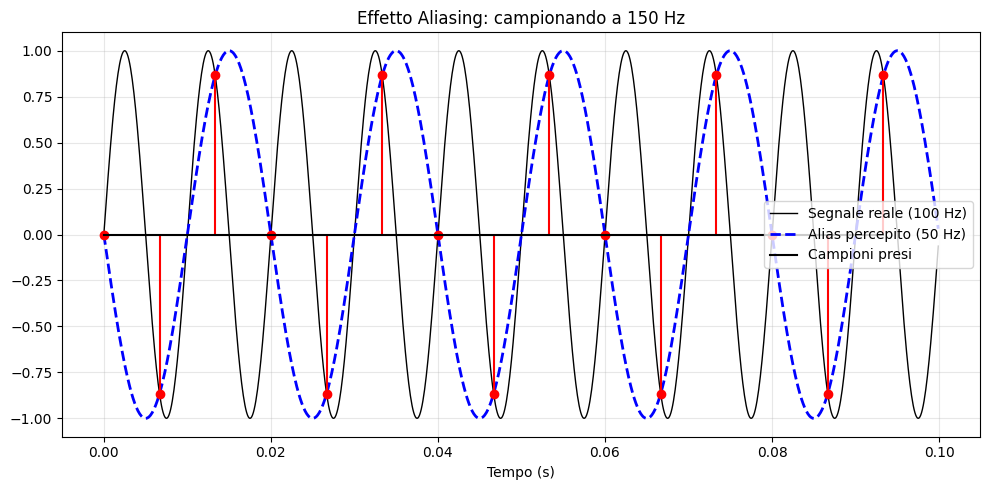

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parametri ---
f_reale = 100
fs = 150
f_alias = abs(fs - f_reale)  # 50 Hz

# --- Vettori temporali ---
fs_alta = 10000
t_reale = np.arange(0, 0.1, 1/fs_alta) # il range è da 0 a 0.1 secondi, la frequenza con cui misura è 10k volte al secondo
t_camp  = np.arange(0, 0.1, 1/fs) # arrange dice: salva tutti i numeri che ci sono tra 0 e 0.1 ogni 1/fs numeri
# restituisce un array da 0.1/(1/1000) = 0.1/0.001 = 1000 elementi

# --- Segnali ---
y_reale = np.sin(2 * np.pi * f_reale * t_reale) # y sarebbe un array di sinusoidi valutate in un tot di t
y_camp  = np.sin(2 * np.pi * f_reale * t_camp)
y_alias = -np.sin(2 * np.pi * f_alias * t_reale)

# --- Grafico ---
plt.figure(figsize=(10, 5))
plt.plot(t_reale, y_reale, 'k',    linewidth=1,   label='Segnale reale (100 Hz)')
plt.plot(t_reale, y_alias, 'b--',  linewidth=2,   label=f'Alias percepito ({f_alias} Hz)')
plt.stem(t_camp,  y_camp,
         linefmt='r-', markerfmt='ro', basefmt='k-')
plt.gca().get_lines()[-1].set_label('Campioni presi')  # etichetta per stem

plt.title(f'Effetto Aliasing: campionando a {fs} Hz')
plt.xlabel('Tempo (s)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Es. 2
- Generare un segnale digitale che rappresenti una nota pura (sinusoide)
alla frequenza di 440 Hz (corrispondente al LA4) per una durata di 2s,
utilizzando una frequenza di campionamento standard di 44100 Hz.
- Cosa accade ai campioni di un segnale se vengono riprodotti a una
frequenza di campionamento fs doppia rispetto a quella di registrazione?
- E a una fs dimezzata rispetto a quella di registrazione?

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parametri ---
f_nota = 440 # LA4
f_camp = 44100
durata = 2

# --- Vettori temporali ---
fs_alta = 10000
t = np.arange(0, durata, 1/f_camp) # misura da 0 a 2 secondi, con 10k misurazioni al secondo. tot misurazioni = 20k
x = np.sin(2 * np.pi * f_nota * t)

# --- Riproduzione audio ---
import sounddevice as sd

sd.play(x, samplerate=44100)
sd.wait()

sd.play(x, samplerate=88200)
sd.wait()

sd.play(x, samplerate=22050)
sd.wait()

from IPython.display import Audio, display
from IPython.core.display import HTML

display(HTML("<b>Originale</b>")); display(Audio(x, rate=44100))
display(HTML("<b>Doppia frequenza</b>")); display(Audio(x, rate=88200))
display(HTML("<b>Metà frequenza</b>")); display(Audio(x, rate=22050))


Es. 3
1. Caricare il file audio chirp_signal.wav (un segnale che parte da una frequenza bassa e sale progressivamente verso l'alto).
2. Estrarre la frequenza di campionamento originale (fs ) dai metadati.
3. Determinare la durata del file e il numero totale di campioni presenti.
4. Sottocampionamento (decimazione) manuale
Invece di usare funzioni di resampling dalle librerie (che applicano filtri automatici),
effettuare una decimazione manuale.
Prendere un campione ogni N (ad esempio N=4 o N=8) per creare un nuovo
segnale. Calcolare la nuova frequenza di campionamento: fnew =fs/N .
5. Analisi della forma d’onda (zoom temporale)
Scegliere due segmenti del segnale da 10 millisecondi ciascuno:
segmento iniziale: dove il chirp ha una frequenza bassa.
segmento finale: dove il chirp raggiunge la frequenza massima.
Confronta visivamente (tramite un grafico temporale) il segnale originale e quello
decimato in questi due punti. Cosa noti nel segmento finale?

Frequenza di campionamento: 44100 Hz
Numero di campioni: 88201
Durata: 2.00 secondi


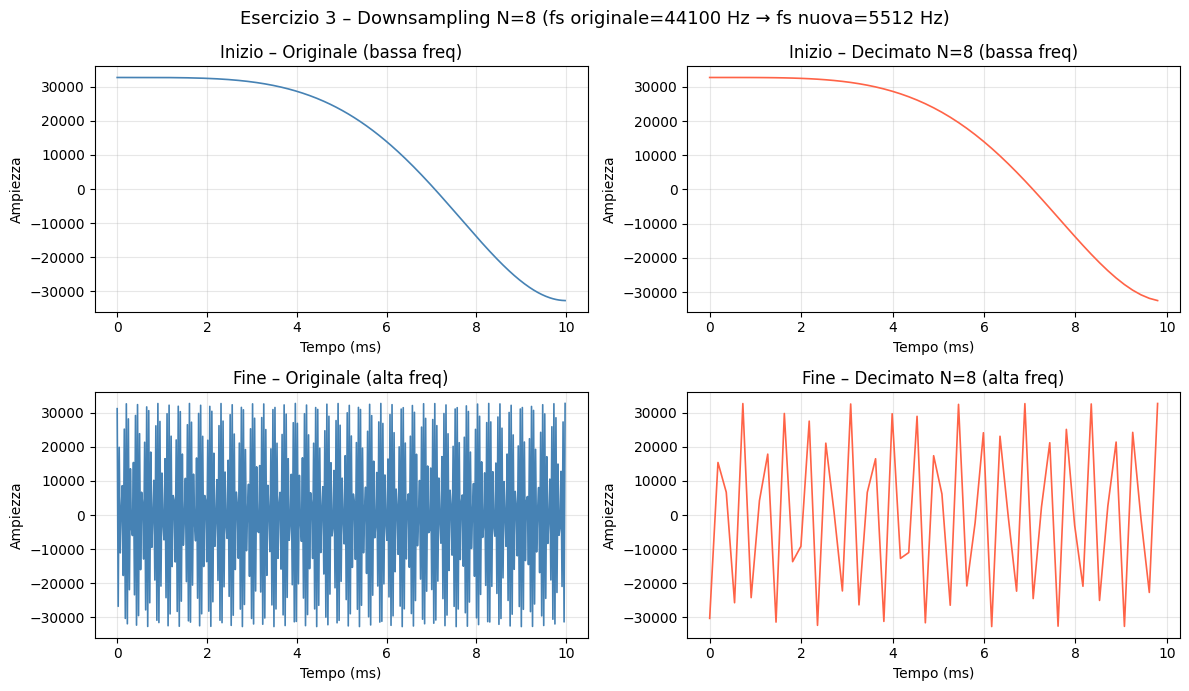

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- Estrapolazione metadati ---
from scipy.io import wavfile

fs, x = wavfile.read('./Materiale/chirp_signal.wav')
# x = x.astype(np.float32) / np.iinfo(x.dtype).max

print(f'Frequenza di campionamento: {fs} Hz')
print(f'Numero di campioni: {len(x)}') # x NON è il numero di campioni, x SONO i campioni
print(f'Durata: {len(x)/fs:.2f} secondi')

durata = len(x)/fs

N = 8 # numero arbitrario
x_dec = x[::N] # ossia prendiamo un campione ogni 8
fnew = fs/N # troviamo

n_camp_orig = int(0.01 * fs)
n_camp_dec  = int(0.01 * fnew)  # campioni in 10ms nel segnale decimato

# Riproduciamo

from IPython.display import Audio, display
from IPython.core.display import HTML

display(HTML("<b>Originale</b>")); display(Audio(x, rate=fs))
display(HTML("<b>Decimato</b>")); display(Audio(x_dec, rate=int(fnew)))


# Zoom temporale di 10ms

n_orig = int(0.01 * fs)      # campioni in 10ms - segnale originale
n_dec  = int(0.01 * fnew)  # campioni in 10ms - segnale decimato

# Segmento iniziale (bassa frequenza)
seg_orig_inizio = x[:n_camp_orig] # prendiamo tutti i campioni dall'inizio a 10 ms, dato che sappiamo quanti campioni ci sono in 10 ms basta prendere dal primo al "n_camp_orig"
seg_dec_inizio  = x_dec[:n_camp_dec] # uguale ma da 0 al numero di campioni in 10ms del campione decimato

# Segmento finale (alta frequenza)
seg_orig_fine = x[-n_camp_orig:] # qui invece prendiamo i campioni dei 10 ms finali dall'audio originale
seg_dec_fine  = x_dec[-n_camp_dec:] # campioni finali dell'audio decimato


# Assi temporali in millisecondi
t_orig = np.arange(n_orig) / fs * 1000
t_dec  = np.arange(n_dec)  / fnew * 1000


# Grafico

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle(f'Esercizio 3 – Downsampling N={N} (fs originale={fs} Hz → fs nuova={fnew:.0f} Hz)',
             fontsize=13)

# Riga 0: segmento iniziale
axes[0, 0].plot(t_orig, seg_orig_inizio, 'steelblue', lw=1.2)
axes[0, 0].set_title('Inizio – Originale (bassa freq)')
axes[0, 0].set_xlabel('Tempo (ms)')
axes[0, 0].set_ylabel('Ampiezza')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(t_dec, seg_dec_inizio, 'tomato', lw=1.2)
axes[0, 1].set_title(f'Inizio – Decimato N={N} (bassa freq)')
axes[0, 1].set_xlabel('Tempo (ms)')
axes[0, 1].set_ylabel('Ampiezza')
axes[0, 1].grid(alpha=0.3)

# Riga 1: segmento finale
axes[1, 0].plot(t_orig, seg_orig_fine, 'steelblue', lw=1.2)
axes[1, 0].set_title('Fine – Originale (alta freq)')
axes[1, 0].set_xlabel('Tempo (ms)')
axes[1, 0].set_ylabel('Ampiezza')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(t_dec, seg_dec_fine, 'tomato', lw=1.2)
axes[1, 1].set_title(f'Fine – Decimato N={N} (alta freq)')
axes[1, 1].set_xlabel('Tempo (ms)')
axes[1, 1].set_ylabel('Ampiezza')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

NOTIAMO:
Con frequenze basse i cicli sono lunghi, ci stanno comunque tanti
campioni anche dopo la decimazione. Con frequenze alte i cicli sono
cortissimi, e saltare 7 campioni su 8 significa perdere quasi tutta la
forma dell'onda. Notiamo nei grafici sovrastanti, che nonostante la
frequenza di campionamento cambi, la linea rimane uguale.
Negli ultimi 10ms, quando la frequenza è al suo massimo, vediamo che il
campionamento fa la differenza per non perdere dati

Es. 4
Dato un segnale sinusoidale x(t)=Asin(2πft) con ampiezza A=1 e frequenza f=50 Hz
1. Calcolare il numero di livelli di quantizzazione disponibili per una risoluzione di 2 bit e 4 bit.
2. Determinare lo step di quantizzazione Δ
Implementazione in Python/MATLAB:
1. Generare il segnale originale con una frequenza di campionamento di 1000 Hz
per una durata di 0.1 s.
2. Implementare una funzione di quantizzazione uniforme che mappi il segnale
continuo sui livelli discreti.
3. Visualizzare il segnale quantizzato, mettendolo a confronto con l'originale.

Scarto quadratico medio 2 bit: 0.051682107654424686
Scarto quadratico medio 4 bit: 0.0014752402718819484
Scarto quadratico medio 5 bit: 0.0003830607050430165
SNR 2 bit: 9.86 dB
SNR 4 bit: 25.30 dB
SNR 5 bit: 31.16 dB


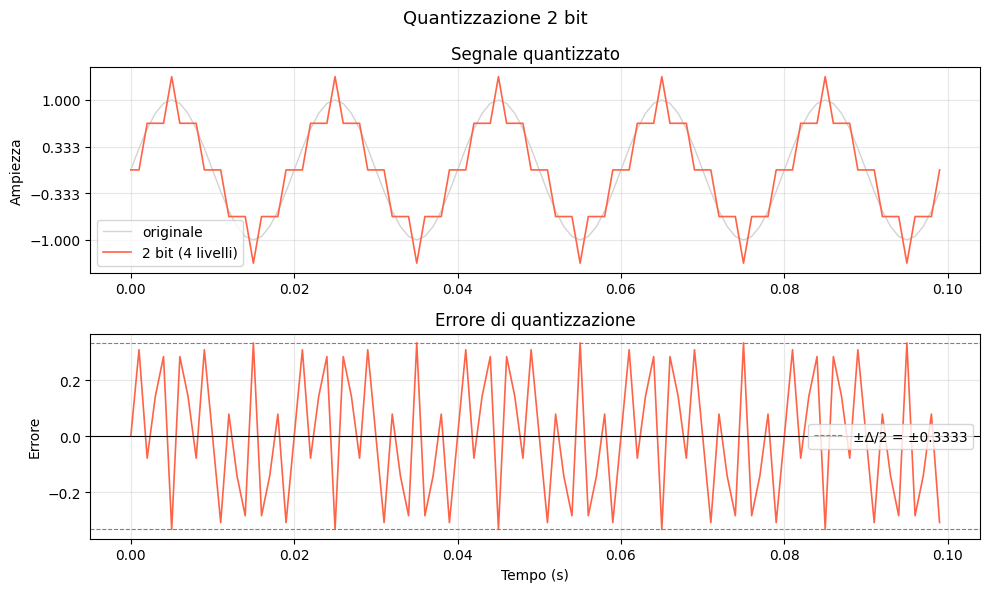

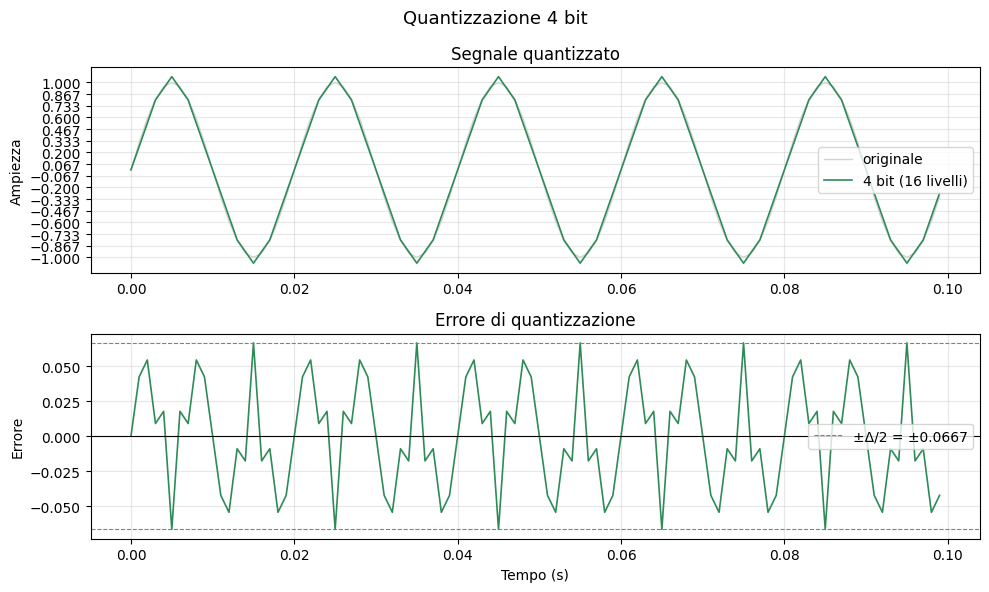

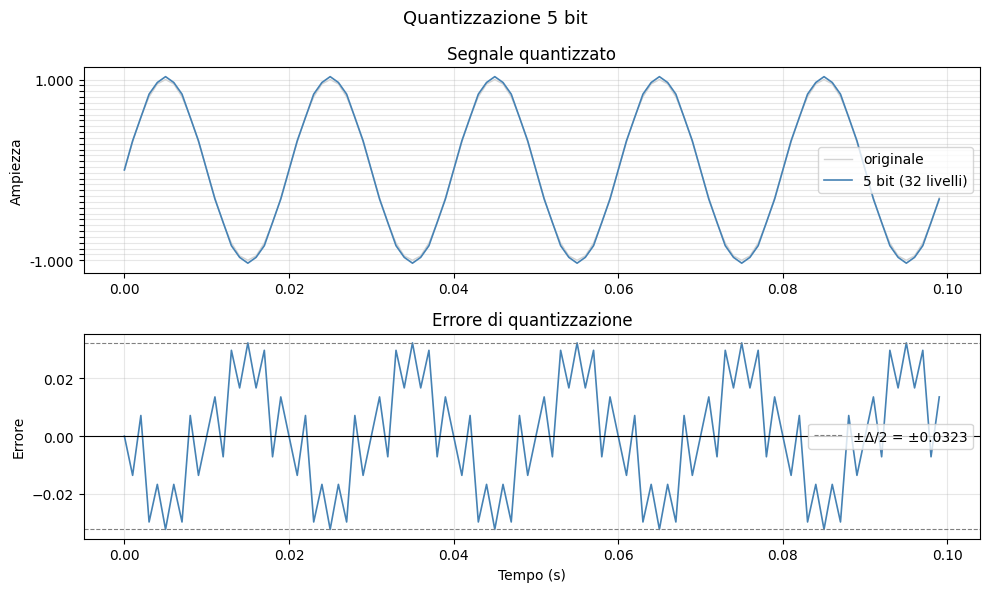

In [15]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import sounddevice as sd

# --- Estrapolazione metadati ---
f = 50
samplerate = 1000
durata = 0.1
A = 1
t = np.arange(0, durata, 1/samplerate)
y = A * np.sin(2 * np.pi * f * t) # potevamo non moltiplicare per A in quanto il seno oscilla tra 1 e -1, dunque la sua ampiezza è 1 di base

liv_quant_2bit = 4 # 2^n_bit
liv_quant_4bit = 16

# step di quantizzazione
delta_2bit = A*2 / (liv_quant_2bit -1) # (liv max - liv min) / n livelli = (1-(-1))/4 = 0.5
delta_4bit = A*2 / (liv_quant_4bit -1) # (1-(-1))/16 = 1/8 = 0.125

# quantizziamo
y_2bit = np.round(y / delta_2bit) * delta_2bit
y_4bit = np.round(y / delta_4bit) * delta_4bit

#oppure possiamo creare una formula di quantizzazione che arrotonda automaticamente ogni valore di y al valore più vicino a nostra disposizione (asse y) in base alla risoluzione
def quantizza(segnale, n_bit, A_min=-1, A_max=1):
    livelli = 2 ** n_bit
    delta = (A_max - A_min) / (livelli - 1)  # we also can do without the -1
    y_quant = np.round(segnale / delta) * delta
    return y_quant

# non è necessario, ma ricalcoliamo y quantizzato con la funzione apposita
y_2bit = quantizza(y, 2)
y_4bit = quantizza(y, 4)

# analisi quantizzazione
"""
1. Calcolare il Segnale Errore (differenza istantanea tra segnale originale e
quantizzato).
2. Calcolare l'Errore Medio Quadratico (MSE) per entrambe le risoluzioni e
commentare come cambia la precisione al raddoppiare dei bit.
3. Se aumentiamo la risoluzione di 1 solo bit (es. da 4 a 5 bit), di quanti decibel
(dB) ci aspettiamo che migliori il rapporto segnale-rumore?
"""

errore_2bit = y - y_2bit # numPy automatically subtracts the value of each element in the array
errore_4bit = y - y_4bit

# note: the signal error for each element can't be higher than delta/2 or lower than -(delta/2)

# MSE
mse_2bit = np.mean(errore_2bit ** 2)
mse_4bit = np.mean(errore_4bit ** 2)

print(f'Scarto quadratico medio 2 bit: {mse_2bit}')
print(f'Scarto quadratico medio 4 bit: {mse_4bit}')
# nota: a 4 bit si riduce notevolmente

#proviamo con 5 bit
y_5bit = quantizza(y, 5)
errore_5bit = y - y_5bit
mse_5bit = np.mean(errore_5bit ** 2)
print(f'Scarto quadratico medio 5 bit: {mse_5bit}')


# calcolo rapporto segnale - rumore in dB
# SNR (dB) = 10 * log10(potenza segnale / potenza rumore)
snr_2bit = 10 * np.log10(np.mean(y**2) / np.mean(errore_2bit**2))
snr_4bit = 10 * np.log10(np.mean(y**2) / np.mean(errore_4bit**2))
snr_5bit = 10 * np.log10(np.mean(y**2) / np.mean(errore_5bit**2))


print(f'SNR 2 bit: {snr_2bit:.2f} dB')
print(f'SNR 4 bit: {snr_4bit:.2f} dB')
print(f'SNR 5 bit: {snr_5bit:.2f} dB')


# Grafici
for n_bit, y_quant, errore, colore in [
    (2, y_2bit, errore_2bit, 'tomato'),
    (4, y_4bit, errore_4bit, 'seagreen'),
    (5, y_5bit, errore_5bit, 'steelblue')
]:
    delta = 2 / ((2 ** n_bit) -1)
    
    fig, axes = plt.subplots(2, 1, figsize=(10, 6))
    fig.suptitle(f'Quantizzazione {n_bit} bit', fontsize=13)

    # Segnale quantizzato
    axes[0].plot(t, y, 'lightgray', lw=1, label='originale')
    axes[0].plot(t, y_quant, color=colore, lw=1.2, label=f'{n_bit} bit ({2**n_bit} livelli)')
    axes[0].set_title('Segnale quantizzato')
    axes[0].set_ylabel('Ampiezza')
    
    # per 5 bit: linee ogni delta ma label solo ogni 0.125 (come 4 bit)
    livelli = np.arange(-1, 1 + delta, delta)
    axes[0].set_yticks(livelli)
    if n_bit == 5:
        label_ticks = np.arange(-1, 1 + 0.125, 0.125)
        axes[0].set_yticklabels([f'{v:.3f}' if any(np.isclose(v, label_ticks)) else '' for v in livelli])

    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Errore
    axes[1].plot(t, errore, color=colore, lw=1.2)
    axes[1].axhline(y=0, color='black', lw=0.8)
    axes[1].axhline(y=delta/2,  color='gray', lw=0.8, linestyle='--', label=f'±Δ/2 = ±{delta/2:.4f}')
    axes[1].axhline(y=-delta/2, color='gray', lw=0.8, linestyle='--')
    axes[1].set_title('Errore di quantizzazione')
    axes[1].set_xlabel('Tempo (s)')
    axes[1].set_ylabel('Errore')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()

plt.show()

Utilizzare un frammento audio complesso per studiare come la riduzione dei livelli di
ampiezza influenzi la qualità del segnale (trovate nella cartella «materiale» alcuni
esempi di audio).
1. Importare un file audio.
2. Estrarre un singolo canale (mono) e normalizzare l'ampiezza nell'intervallo [−1,1].
3. Utilizzare la funzione di quantizzazione implementata nell'esercizio 4 per
ridurre la risoluzione del segnale originale a 8, 4 e 2 bit.
Test d'Ascolto e Confronto:
1. Riprodurre le versioni a risoluzione ridotta. Descrivere come cambia la
percezione del suono.
2. Riprodurre il segnale rumore a 2 bit. Cosa si sente? 

In [16]:
import numpy as np
import sounddevice as sd
from scipy.io import wavfile

# we extract the audio into an array (data)
fs, data = wavfile.read('Materiale/gong.wav')

# if the data is stereo, we take the average of the two channels
if data.ndim == 2:
    data = data.mean(axis=1)

data = data.astype(np.float64)
data = data / np.max(np.abs(data)) # easy normalization step: we make everything positive, find the max value of the data array, and devide each component with that maximum

def quantizza(segnale, n_bit, A_min=-1, A_max=1):
    livelli = 2 ** n_bit
    delta = (A_max - A_min) / (livelli - 1)  # we also can do without the -1
    segnale_clipped = np.clip(segnale, A_min, A_max)
    y_quant = np.round((segnale_clipped - A_min) / delta) * delta + A_min
    return y_quant

data8bit = quantizza(data, 8)
data4bit = quantizza(data, 4)
data2bit = quantizza(data, 2)

from IPython.display import Audio, display
from IPython.core.display import HTML

display(HTML("<b>Originale</b>")); display(Audio(data, rate=fs))
display(HTML("<b>8 bit</b>")); display(Audio(data8bit, rate=fs))
display(HTML("<b>4 bit</b>")); display(Audio(data4bit, rate=fs))
display(HTML("<b>2 bit</b>")); display(Audio(data2bit, rate=fs))

Applicazione del Dither:
1. Generare un vettore di rumore casuale con ampiezza pari allo step di
quantizzazione Δ.
2. Sommare questo rumore al segnale analogico.
3. Effettuare la quantizzazione a 4 bit sul segnale così modificato.